В задании используется база курса акций Лукойла.

1. Обучите простую полносвязную сеть для прогнозирования временного ряда (только close) и визуализируйте результат.

2. Обучите такую же архитектуру сети на прогнозирование на 10 шагов вперёд прямым способом и визуализируйте результат.

3. Постройте графики сравнения предсказания с оригинальным сигналом по всем 10 шагам предсказания (10 графиков на разных отдельных осях).

4. Сделайте те же задания с другой сетью, которая будет использовать Conv1D или LSTM слои.


## Подготовка данных

Загрузка библиотек

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

Загрузка базы

In [ ]:
# Загрузка датасетов из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [ ]:
# Чтение данных в таблицу pandas
base_data = pd.read_csv('18_19.csv', sep=';')

In [ ]:
# Вывод первых строк таблицы
base_data.head()

,DATE,TIME,OPEN,MAX,MIN,CLOSE,VOLUME
0,03.01.2018,10:00:00,3341.0,3356.0,3340.0,3355.0,6088
1,03.01.2018,10:01:00,3355.0,3359.0,3353.0,3353.0,1624
2,03.01.2018,10:02:00,3351.5,3357.5,3351.5,3357.5,722
3,03.01.2018,10:03:00,3354.5,3360.0,3354.5,3358.0,3034
4,03.01.2018,10:04:00,3358.0,3360.0,3351.5,3360.0,1427


In [ ]:
# Загрузка датасетов с удалением ненужных столбцов по дате и времени

data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

In [ ]:
# Просмотр размерностей получившихся табли

print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [ ]:
# Пример данных одного датасета
d = data18_19

print(d.shape[0])  # Всего записей (строк)
print(d.shape[1])  # Количество столбцов
print(d.iloc[0])   # Пример нулевой строки данных

217947
5
OPEN      3341.0
MAX       3356.0
MIN       3340.0
CLOSE     3355.0
VOLUME    6088.0
Name: 0, dtype: float64


In [ ]:
# Создание общего набора данных из двух датасетов

data = pd.concat([data16_17, data18_19]).to_numpy()

In [ ]:
# Просмотр размерности новой таблицы

print(data16_17.shape)
print(data18_19.shape)
print(data.shape)

(263925, 5)
(217947, 5)
(481872, 5)


In [ ]:
# Задание текстовых меток каналов данных (столбцов)

channel_names = ['Open', 'Max', 'Min', 'Close', 'Volume']

Иллюстрация данных в графическом виде

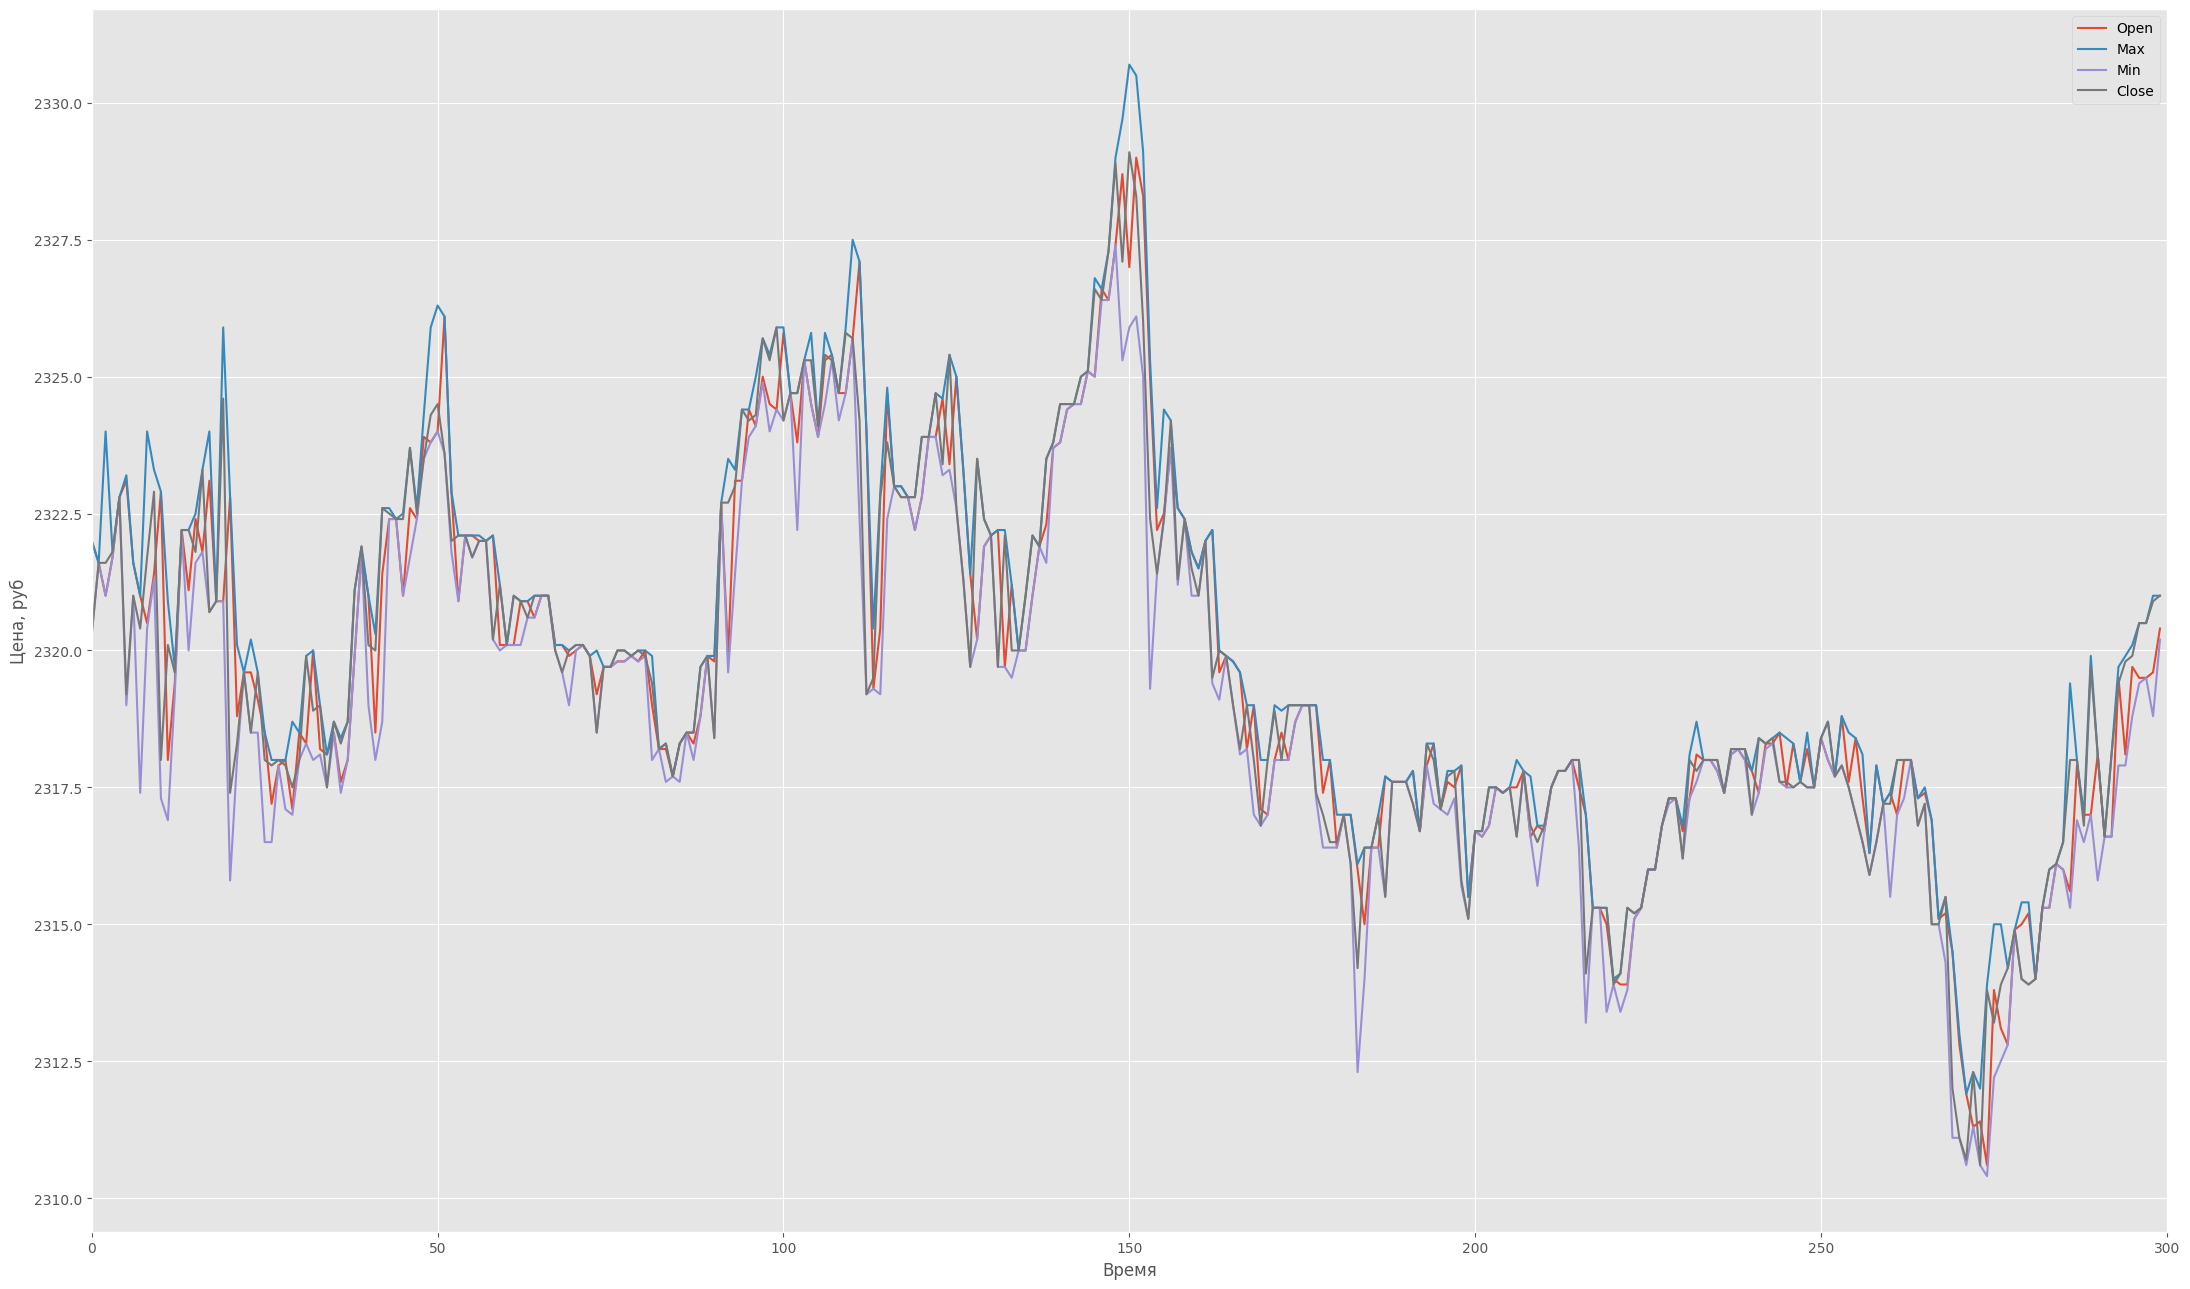

In [ ]:
# Отображение исходных данных от точки start и длинной length
start = 100
length = 300

# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, ax = plt.subplots(figsize=(22, 13), sharex=True)

# Четыре основных канала - open, max, min, close
for chn in range(4):
    # Отрисовка одного канала данных
    # От начальной точки start длиной length
    ax.plot(data[start:start + length, chn],
             label=channel_names[chn])
ax.set_ylabel('Цена, руб')
ax.legend()
plt.xlabel('Время')

# Регулировка пределов оси x
plt.xlim(0, length)

# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()

# Фиксация графика
plt.show()

Обучите простую полносвязную сеть для прогнозирования временного ряда (только close) и визуализируйте результат.

In [ ]:
from pandas.core.api import DataFrame
import pandas as pd
df = DataFrame(data)
df.head()

,0,1,2,3,4
0,2351.0,2355.8,2350.0,2350.0,2547.0
1,2352.9,2355.7,2350.0,2355.7,195.0
2,2355.6,2356.0,2351.4,2354.1,257.0
3,2354.5,2355.0,2351.2,2353.7,763.0
4,2353.1,2353.9,2353.1,2353.6,231.0


ПОДГОТОВКА ДАННЫХ (только Close)

In [ ]:
# Создаем словарь:
# название признака - индекс столбца
CHANNEL_INDEX = {name: i for i, name in enumerate(CHANNEL_NAMES)}
# Используем только цену закрытия (Close)
CHANNEL_X = ['Close']
CHANNEL_Y = ['Close']
# Модель анализирует последние 300 точек
SEQ_LEN = 300
# Количество прогнозируемых шагов вперед
PRED_STEPS = 10
BATCH_SIZE = 32
TEST_LEN = 30000

TRAIN_LEN = data.shape[0] - TEST_LEN
# Получаем индексы нужных столбцов
chn_x = [CHANNEL_INDEX[c] for c in CHANNEL_X]
chn_y = [CHANNEL_INDEX[c] for c in CHANNEL_Y]

# train / test
data_train = data[:TRAIN_LEN]
# Добавляем разрыв 2 * SEQ_LEN,
# чтобы избежать пересечения окон
data_test = data[TRAIN_LEN + 2 * SEQ_LEN:]

# выделяем только close
x_data_train = data_train[:, chn_x]
x_data_test = data_test[:, chn_x]

y_data_train = data_train[:, chn_y]
y_data_test = data_test[:, chn_y]

# масштабирование
x_scaler = MinMaxScaler()
x_data_train = x_scaler.fit_transform(x_data_train)
x_data_test = x_scaler.transform(x_data_test)

y_scaler = MinMaxScaler()
y_data_train = y_scaler.fit_transform(y_data_train)
y_data_test = y_scaler.transform(y_data_test)
# Размерность
print(x_data_train.shape)
print(x_data_test.shape)

(451872, 1)
(29400, 1)


СОЗДАНИЕ ВЫБОРОК ДЛЯ ПРОГНОЗА НА 1 ШАГ

In [ ]:
# Формирует последовательности длиной SEQ_LEN
# и соответствующее целевое значение
train_gen_1 = TimeseriesGenerator(
    x_data_train,
    y_data_train,
    length=SEQ_LEN,
    batch_size=BATCH_SIZE
)
# тоже самое для вал
val_gen_1 = TimeseriesGenerator(
    x_data_test,
    y_data_test,
    length=SEQ_LEN,
    batch_size=BATCH_SIZE
)
# тот же процесс для тест
test_gen_1 = TimeseriesGenerator(
    x_data_test,
    y_data_test,
    length=SEQ_LEN,
    batch_size=len(x_data_test)
)
# Получение тестовой выборки в формате numpy-массивов
x_test_1, y_test_1 = test_gen_1[0]

print(x_test_1.shape)
print(y_test_1.shape)

(29100, 300, 1)
(29100, 1)


DENSE СЕТЬ ПРЕДСКАЗЫВАЮЩАЯ ЗНАЧЕНИЕ НА 1 ШАГ

In [ ]:
model_dense_1 = Sequential([
    Flatten(input_shape=x_test_1.shape[1:]),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model_dense_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

history_dense_1 = model_dense_1.fit(
    train_gen_1,
    validation_data=val_gen_1,
    epochs=15,
    verbose=1
)

Epoch 1/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 4.4300e-04 - mae: 0.0102 - val_loss: 3.0857e-04 - val_mae: 0.0168
Epoch 2/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 7.1244e-05 - mae: 0.0057 - val_loss: 6.3659e-05 - val_mae: 0.0066
Epoch 3/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - loss: 4.6409e-05 - mae: 0.0047 - val_loss: 7.2899e-05 - val_mae: 0.0073
Epoch 4/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 3.4935e-05 - mae: 0.0041 - val_loss: 1.6407e-04 - val_mae: 0.0120
Epoch 5/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 2.8254e-05 - mae: 0.0038 - val_loss: 2.3215e-05 - val_mae: 0.0036
Epoch 6/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 2.4610e-05 - mae: 0.0035 - val_loss: 2.8729e-05 - val_mae: 0.0044
Epoch 7/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 2.4151e-05 - mae: 0.0035 - val_loss: 2.5228e-05 - val_mae: 0.0040
Epoch 8/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 2.3111e-05 - mae: 

ВИЗУАЛИЗАЦИЯ ПРОГНОЗА DENSE-СЕТИ НА 1 ШАГ

910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


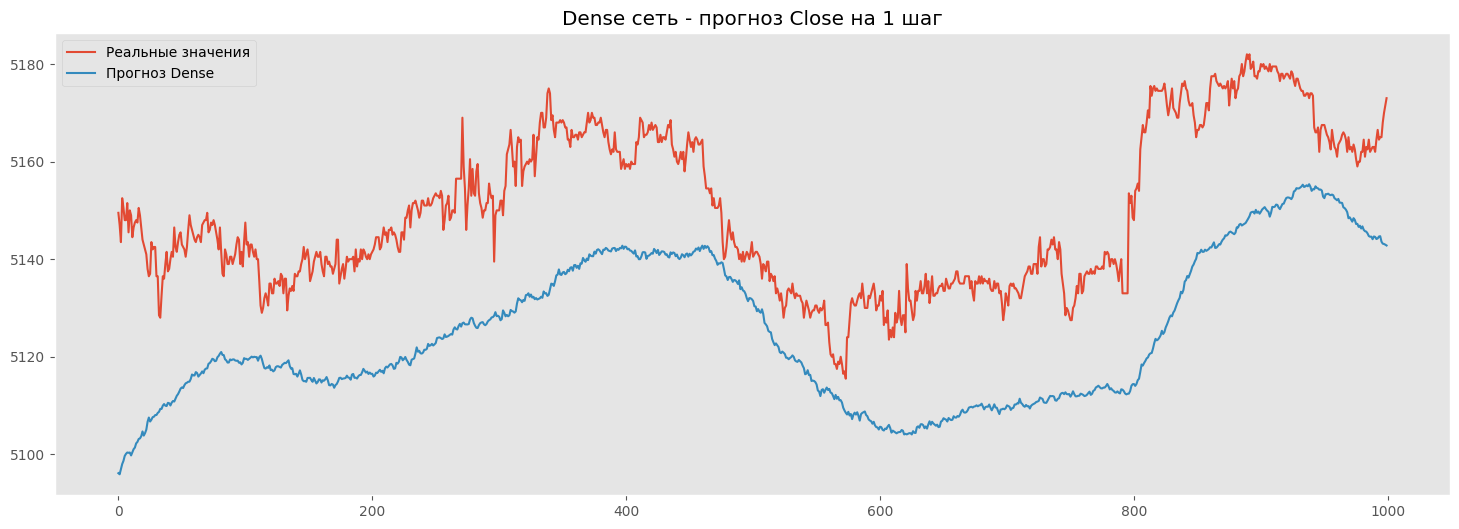

In [ ]:
pred_dense_1 = model_dense_1.predict(x_test_1)

pred_dense_1 = y_scaler.inverse_transform(pred_dense_1)
y_test_real_1 = y_scaler.inverse_transform(y_test_1)

plt.figure(figsize=(18,6))

plt.plot(
    y_test_real_1[:1000],
    label='Реальные значения'
)

plt.plot(
    pred_dense_1[:1000],
    label='Прогноз Dense'
)

plt.title('Dense сеть - прогноз Close на 1 шаг')
plt.legend()
plt.grid()
plt.show()

ПОДГОТОВКА ДАННЫХ ДЛЯ ПРОГНОЗА НА 10 ШАГОВ ВПЕРЁД

In [ ]:
# Функция формирования выборки
def make_multistep_data(x, y, seq_len=300, pred_steps=10):
    X, Y = [], []
    # Формирование последовательностей
    for i in range(len(x) - seq_len - pred_steps):
       # История длиной seq_len
        X.append(x[i:i+seq_len])
        # Следующие pred_steps значений
        Y.append(y[i+seq_len:i+seq_len+pred_steps].flatten())

    return np.array(X), np.array(Y)
# Формирование обучающей выборки
x_train_10, y_train_10 = make_multistep_data(
    x_data_train,
    y_data_train,
    SEQ_LEN,
    PRED_STEPS
)
# Формирование тестовой выборки
x_test_10, y_test_10 = make_multistep_data(
    x_data_test,
    y_data_test,
    SEQ_LEN,
    PRED_STEPS
)

print(x_train_10.shape)
print(y_train_10.shape)

(451562, 300, 1)
(451562, 10)


DENSE СЕТЬ ПРЕДСКАЗЫВАЮЩАЯ ЗНАЧЕНИЕ НА 1 ШАГ

In [ ]:
model_dense_10 = Sequential([
    Flatten(input_shape=(SEQ_LEN, 1)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(PRED_STEPS)
])

model_dense_10.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

history_dense_10 = model_dense_10.fit(
    x_train_10,
    y_train_10,
    validation_data=(x_test_10, y_test_10),
    epochs=15,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 2.3177e-04 - mae: 0.0037 - val_loss: 2.4308e-05 - val_mae: 0.0038
Epoch 2/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 1.2050e-05 - mae: 0.0025 - val_loss: 2.8762e-05 - val_mae: 0.0043
Epoch 3/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 9.7543e-06 - mae: 0.0022 - val_loss: 3.2276e-05 - val_mae: 0.0046
Epoch 4/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 8.5977e-06 - mae: 0.0021 - val_loss: 4.3344e-05 - val_mae: 0.0059
Epoch 5/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 7.7294e-06 - mae: 0.0020 - val_loss: 1.0442e-05 - val_mae: 0.0024
Epoch 6/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 7.2114e-06 - mae: 0.0019 - val_loss: 1.0008e-05 - val_mae: 0.0023
Epoch 7/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 6.5596e-06 - mae: 0.0018 - val_loss: 1.2816e-05 - val_mae: 0.0025
Epoch 8/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 6.0505e-06 - mae: 

ВИЗУАЛИЗАЦИЯ ПРОГНОЗА DENSE-СЕТИ НА 10 ШАГОВ

910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


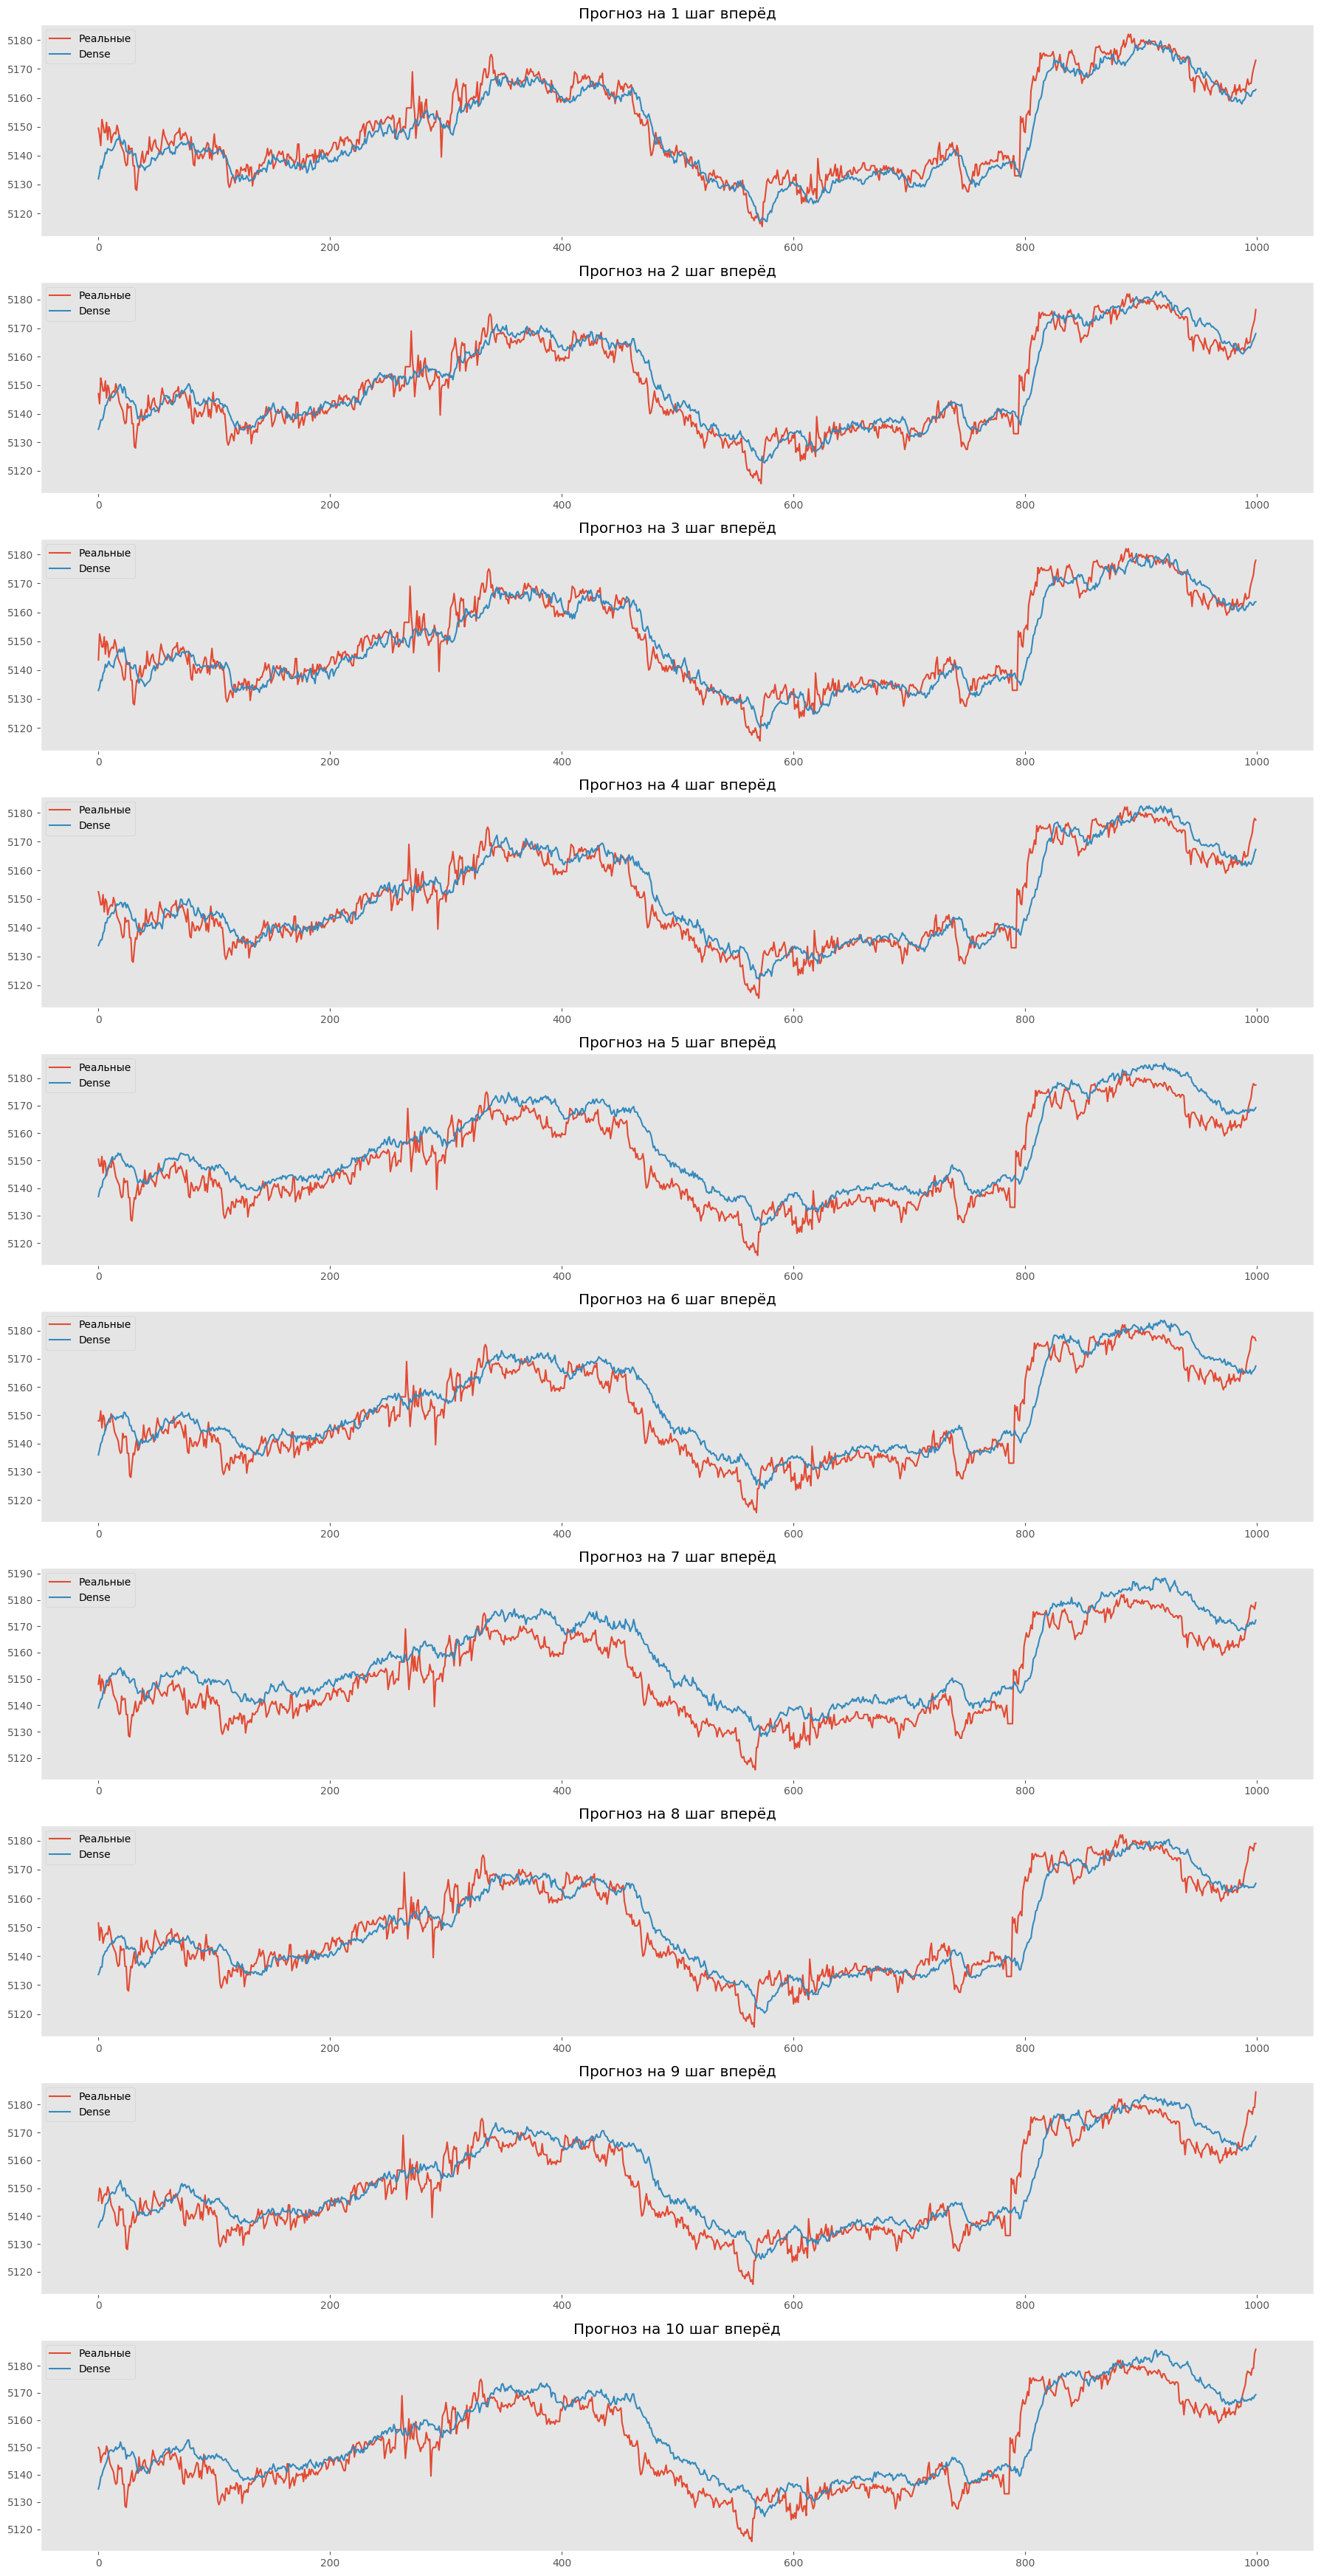

In [ ]:
pred_dense_10 = model_dense_10.predict(x_test_10)

pred_dense_10_real = y_scaler.inverse_transform(
    pred_dense_10.reshape(-1,1)
).reshape(pred_dense_10.shape)

y_test_10_real = y_scaler.inverse_transform(
    y_test_10.reshape(-1,1)
).reshape(y_test_10.shape)

fig, axes = plt.subplots(10, 1, figsize=(18,35))

for i in range(10):

    axes[i].plot(
        y_test_10_real[:1000, i],
        label='Реальные'
    )

    axes[i].plot(
        pred_dense_10_real[:1000, i],
        label='Dense'
    )

    axes[i].set_title(f'Прогноз на {i+1} шаг вперёд')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

LSTM СЕТЬ ДЛЯ ПРОГНОЗА НА 1 ШАГ

In [ ]:
model_lstm_1 = Sequential([
    LSTM(64, input_shape=(SEQ_LEN,1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

history_lstm_1 = model_lstm_1.fit(
    train_gen_1,
    validation_data=val_gen_1,
    epochs=15,
    verbose=1
)

Epoch 1/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 189s 13ms/step - loss: 8.8378e-04 - mae: 0.0054 - val_loss: 6.1603e-06 - val_mae: 0.0021
Epoch 2/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 184s 13ms/step - loss: 7.4739e-06 - mae: 0.0017 - val_loss: 2.0154e-06 - val_mae: 0.0010
Epoch 3/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 188s 13ms/step - loss: 4.2113e-06 - mae: 0.0013 - val_loss: 1.2588e-06 - val_mae: 7.1021e-04
Epoch 4/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 184s 13ms/step - loss: 3.9146e-06 - mae: 0.0012 - val_loss: 1.2550e-06 - val_mae: 7.4504e-04
Epoch 5/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 184s 13ms/step - loss: 3.1128e-06 - mae: 0.0011 - val_loss: 2.0492e-06 - val_mae: 0.0011
Epoch 6/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 184s 13ms/step - loss: 2.4342e-06 - mae: 0.0010 - val_loss: 1.4432e-06 - val_mae: 8.9928e-04
Epoch 7/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 186s 13ms/step - loss: 2.8046e-06 - mae: 9.7729e-04 - val_loss: 1.0703e-06 - val_mae: 7.1023e-04
Epoch 8/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 183s 

ВИЗУАЛИЗАЦИЯ ПРОГНОЗА LSTM-СЕТИ НА 1 ШАГ

910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


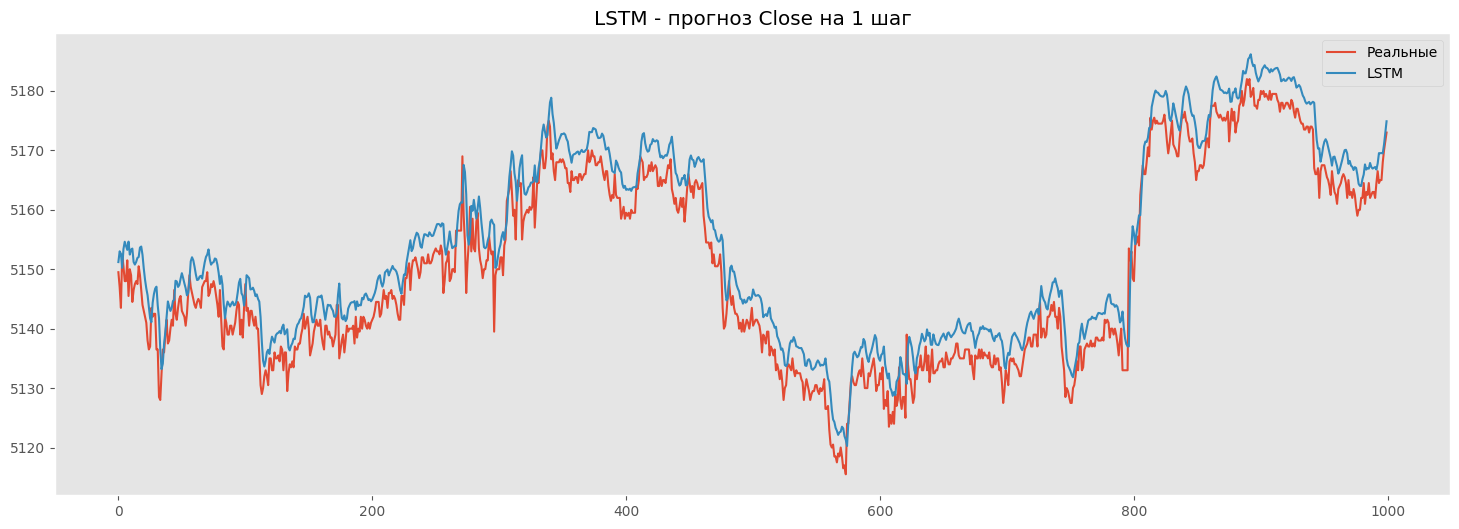

In [ ]:
pred_lstm_1 = model_lstm_1.predict(x_test_1)

pred_lstm_1 = y_scaler.inverse_transform(pred_lstm_1)

plt.figure(figsize=(18,6))

plt.plot(
    y_test_real_1[:1000],
    label='Реальные'
)

plt.plot(
    pred_lstm_1[:1000],
    label='LSTM'
)

plt.title('LSTM - прогноз Close на 1 шаг')
plt.legend()
plt.grid()

plt.show()

ВИЗУАЛИЗАЦИЯ ПРОГНОЗА LSTM-СЕТИ НА 10 ШАГОВ

In [ ]:
model_lstm_10 = Sequential([
    LSTM(64, input_shape=(SEQ_LEN,1)),
    Dense(32, activation='relu'),
    Dense(PRED_STEPS)
])

model_lstm_10.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

history_lstm_10 = model_lstm_10.fit(
    x_train_10,
    y_train_10,
    validation_data=(x_test_10, y_test_10),
    epochs=15,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 183s 13ms/step - loss: 0.0011 - mae: 0.0051 - val_loss: 7.2067e-06 - val_mae: 0.0019
Epoch 2/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 180s 13ms/step - loss: 4.8964e-06 - mae: 0.0016 - val_loss: 4.6976e-06 - val_mae: 0.0014
Epoch 3/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 179s 13ms/step - loss: 4.0715e-06 - mae: 0.0014 - val_loss: 4.2352e-06 - val_mae: 0.0013
Epoch 4/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 179s 13ms/step - loss: 3.5701e-06 - mae: 0.0013 - val_loss: 5.7405e-06 - val_mae: 0.0018
Epoch 5/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 206s 13ms/step - loss: 3.2658e-06 - mae: 0.0012 - val_loss: 6.1274e-06 - val_mae: 0.0019
Epoch 6/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 180s 13ms/step - loss: 3.0607e-06 - mae: 0.0012 - val_loss: 1.9797e-05 - val_mae: 0.0041
Epoch 7/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 179s 13ms/step - loss: 2.8723e-06 - mae: 0.0012 - val_loss: 5.1553e-06 - val_mae: 0.0017
Epoch 8/15
14112/14112 ━━━━━━━━━━━━━━━━━━━━ 205s 13ms/step - loss: 2.7471

ВИЗУАЛИЗАЦИЯ ПРОГНОЗА LSTM-СЕТИ НА 10 ШАГОВ

910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


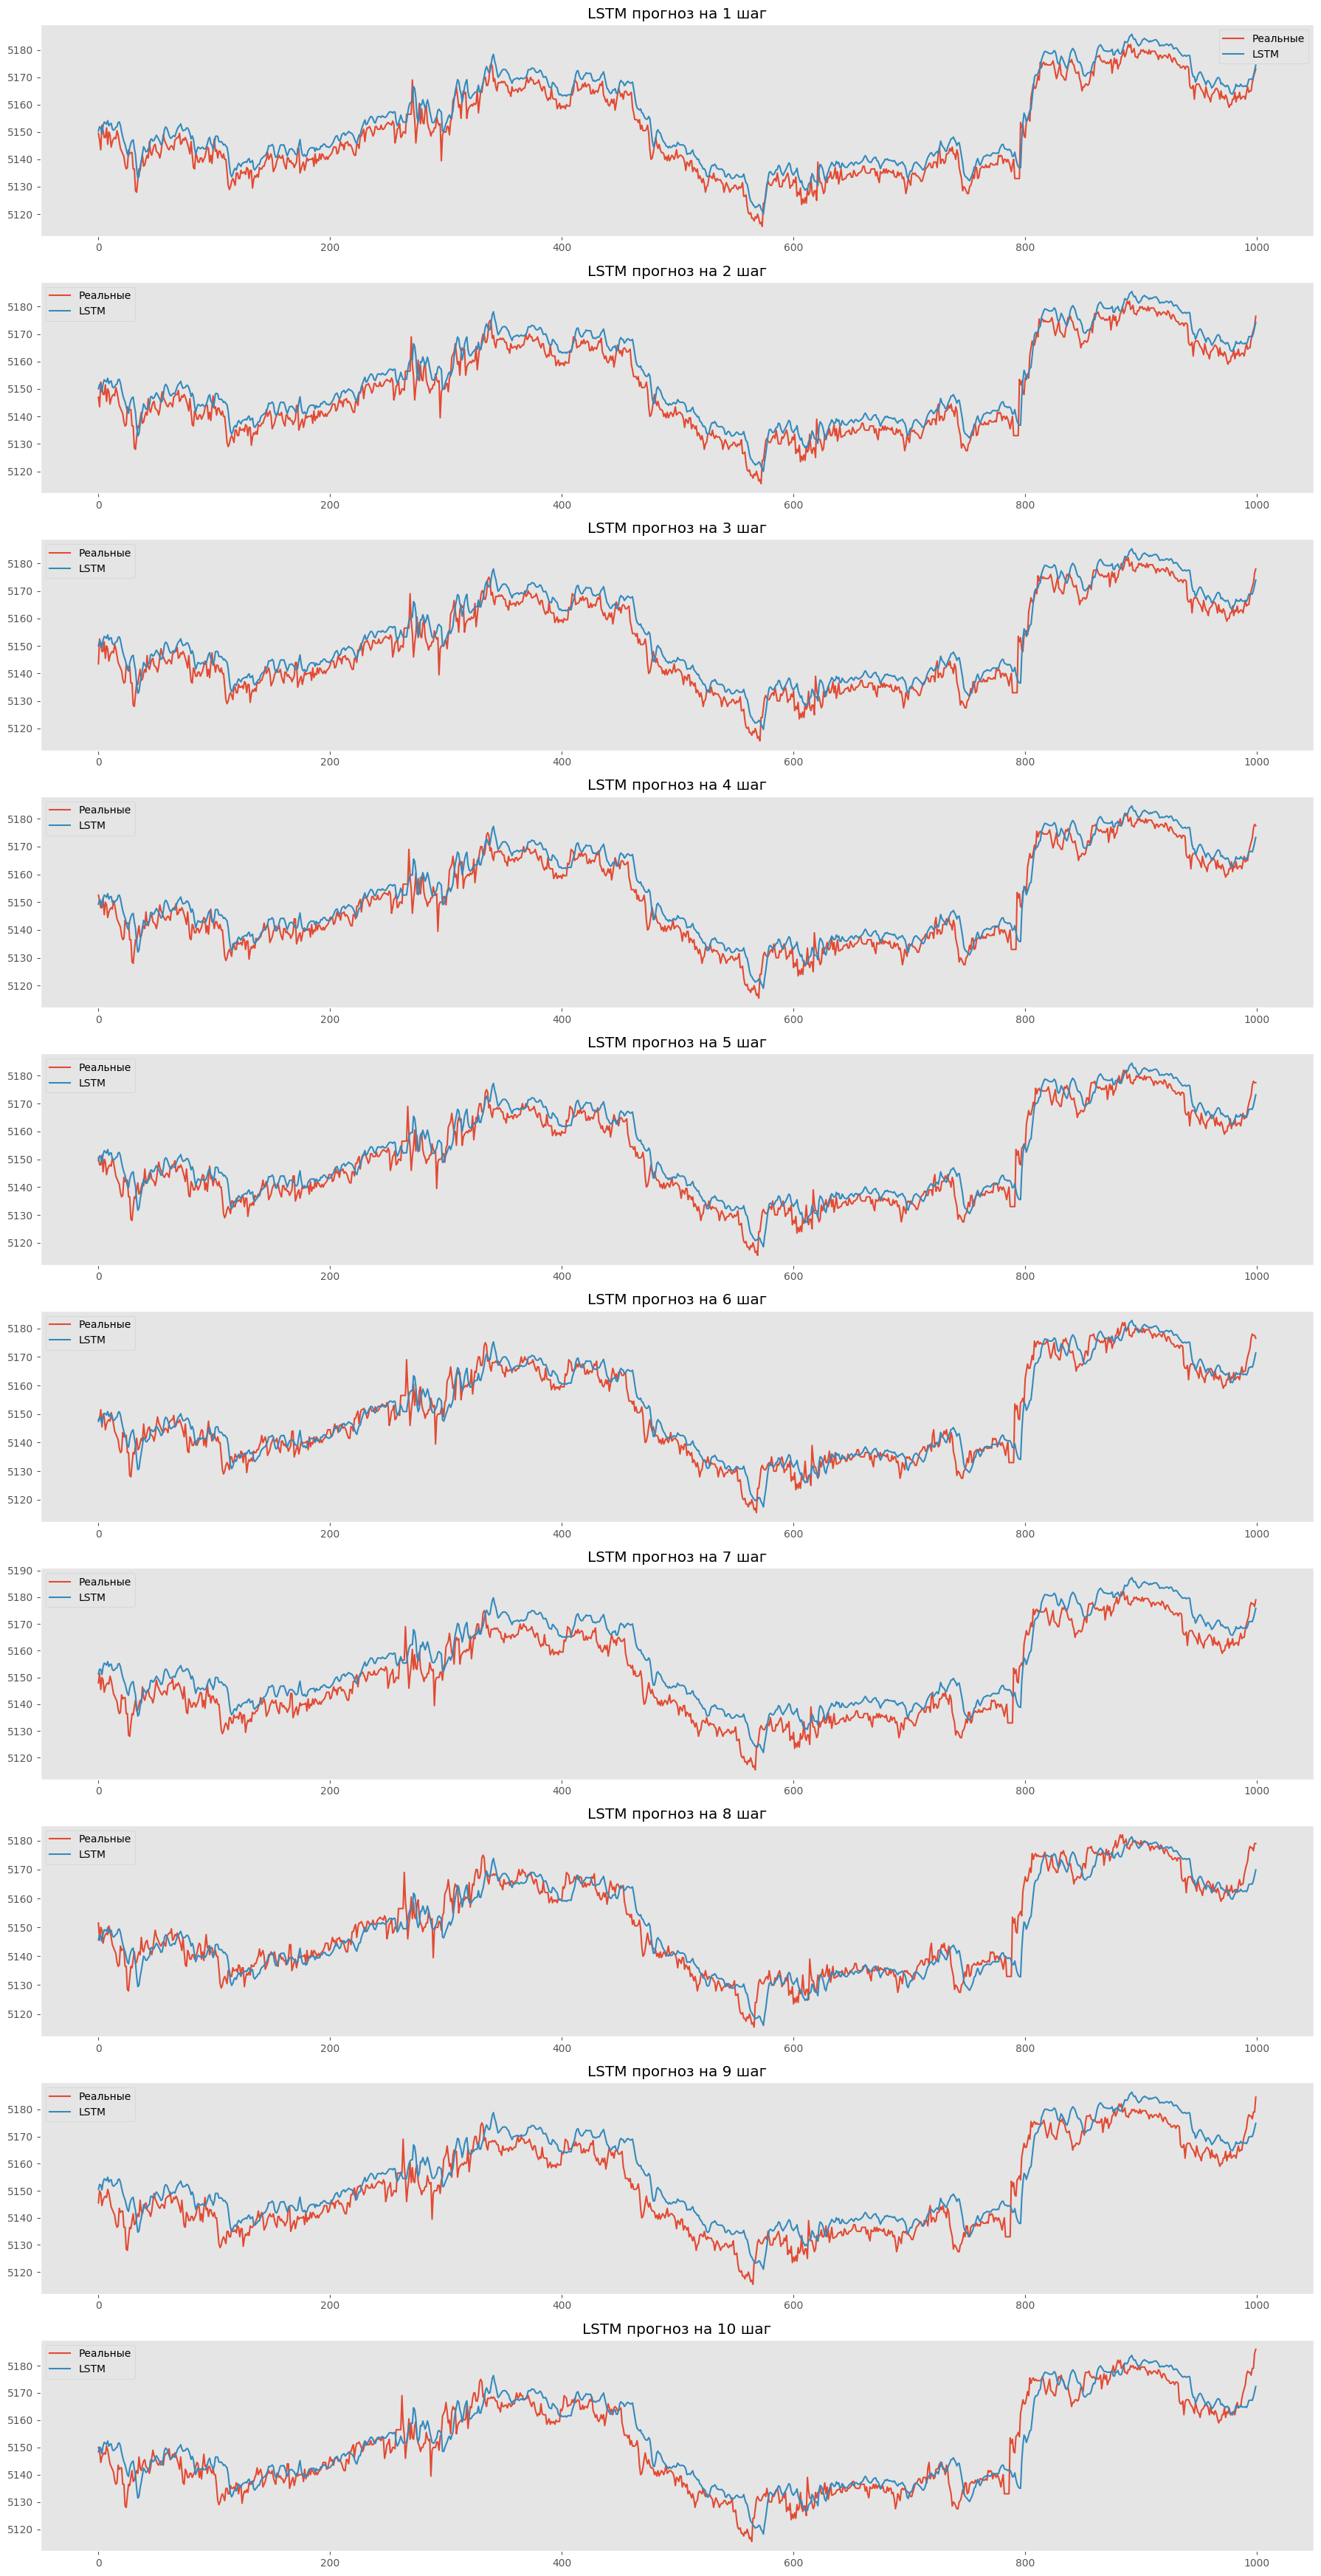

In [ ]:
pred_lstm_10 = model_lstm_10.predict(x_test_10)

pred_lstm_10_real = y_scaler.inverse_transform(
    pred_lstm_10.reshape(-1,1)
).reshape(pred_lstm_10.shape)

fig, axes = plt.subplots(10,1, figsize=(18,35))

for i in range(10):

    axes[i].plot(
        y_test_10_real[:1000, i],
        label='Реальные'
    )

    axes[i].plot(
        pred_lstm_10_real[:1000, i],
        label='LSTM'
    )

    axes[i].set_title(f'LSTM прогноз на {i+1} шаг')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()